In [1]:
import timeit

# Testando o tempo de uma list comprehension
tempo = timeit.timeit('[x**2 for x in range(1000)]', number=10000)
print(f"Tempo médio: {tempo} segundos")

Tempo médio: 0.2874195000003965 segundos


In [2]:
import time

inicio = time.perf_counter()

# O teu algoritmo de Machine Learning ou Ordenação aqui
# ex: shellSort(minha_lista, gaps)

fim = time.perf_counter()
print(f"Duração da execução: {fim - inicio:.6f} segundos")

Duração da execução: 0.000012 segundos


In [3]:
import time
import random
import pandas as pd

# Algoritmo 1: Insertion Sort (O Clássico O(n^2))
def insertionSort(V):
    for j in range(1, len(V)):
        key = V[j]
        i = j - 1
        while i >= 0 and V[i] > key:
            V[i + 1] = V[i]
            i -= 1
        V[i + 1] = key

# Algoritmo 2: Shell Sort (O Evoluído - Complexidade depende dos gaps)
def shellSort(V):
    N = len(V)
    # Sequência de gaps de Shell: N/2, N/4...
    h = N // 2
    while h > 0:
        for i in range(h, N):
            key = V[i]
            j = i
            while j >= h and V[j - h] > key:
                V[j] = V[j - h]
                j -= h
            V[j] = key
        h //= 2

In [4]:
lista_int = [64, 34, 25, 12, 22, 11, 90]
lista_teste = lista_int.copy()
shellSort(lista_teste)
print(f"Lista Original: {lista_int}")
print(f"Lista Ordenada (Shell): {lista_teste}")

Lista Original: [64, 34, 25, 12, 22, 11, 90]
Lista Ordenada (Shell): [11, 12, 22, 25, 34, 64, 90]


In [5]:
data = {
    'Cliente': ['Armand', 'Ana', 'Bruno', 'Carla'],
    'Score': [95, 88, 92, 85]
}
df = pd.DataFrame(data)

# No mundo real, converteríamos a coluna para lista para usar os nossos algoritmos
scores = df['Score'].tolist()
shellSort(scores)
df_ordenado = pd.DataFrame({'Score_Ordenado': scores})
print("\nExemplo DataFrame (Scores Ordenados):")
print(df_ordenado)


Exemplo DataFrame (Scores Ordenados):
   Score_Ordenado
0              85
1              88
2              92
3              95


In [6]:
# Criar massa de dados (5.000 elementos)
tamanho = 5000
dados_aleatorios = [random.randint(0, 10000) for _ in range(tamanho)]

# Testar InsertionSort
lista_ins = dados_aleatorios.copy()
inicio = time.perf_counter()
insertionSort(lista_ins)
fim = time.perf_counter()
tempo_ins = fim - inicio

# Testar ShellSort
lista_shell = dados_aleatorios.copy()
inicio = time.perf_counter()
shellSort(lista_shell)
fim = time.perf_counter()
tempo_shell = fim - inicio

print(f"\n--- RESULTADO DO BENCHMARK ({tamanho} elementos) ---")
print(f"InsertionSort: {tempo_ins:.5f} segundos")
print(f"ShellSort:     {tempo_shell:.5f} segundos")
print(f"Melhoria:      {((tempo_ins/tempo_shell)):.1f}x mais rápido!")


--- RESULTADO DO BENCHMARK (5000 elementos) ---
InsertionSort: 0.28163 segundos
ShellSort:     0.00648 segundos
Melhoria:      43.5x mais rápido!


In [7]:
import perfplot
import numpy as np

print("Perfplot instalado com sucesso!")

Perfplot instalado com sucesso!


In [14]:
import numpy as np

array1 = np.random.rand(20)
array2 = np.random.rand(20)

res1 = np.c_[array1, array2]
res2 = np.stack([array1, array2]).T
res3 = np.vstack([array1, array2]).T
res4 = np.column_stack([array1, array2])
res5 = np.concatenate([array1[:, None], array2[:, None]], axis=1)

print(np.array_equal(res1, res2))
print(np.array_equal(res2, res3))
print(np.array_equal(res3, res4))
print(np.array_equal(res4, res5))

True
True
True
True


In [20]:
import perfplot
import numpy as np  # Essencial: sem isto, os 'np.' dão erro

perfplot.bench(
    setup=lambda n: np.random.rand(n), # O setup precisa receber 'n' para saber o tamanho do array
    kernels=[
        lambda a: np.c_[a, a],
        lambda a: np.stack([a, a]).T,
        lambda a: np.vstack([a, a]).T,
        lambda a: np.column_stack([a, a]),
        lambda a: np.concatenate([a[:, None], a[:, None]], axis=1)
    ], # Precisavas desta vírgula aqui
    labels=["c_", "stack", "vstack", "column_stack", "concat"],
    n_range=[2**k for k in range(15)],
    xlabel="len(a)"
)



Output()

┏━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ n     ┃ c_                 ┃ stack              ┃ vstack             ┃ column_stack       ┃ concat              ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ 1     │ 3.200000000000000… │ 1.600000000000000… │ 1.600000000000000… │ 1.400000000000000… │ 8.000000000000001e… │
│ 2     │ 3.200000000000000… │ 1.600000000000000… │ 1.600000000000000… │ 1.400000000000000… │ 8.000000000000001e… │
│ 4     │ 3.200000000000000… │ 1.7e-06            │ 4.5e-06            │ 3.8e-06            │ 2.7e-06             │
│ 8     │ 8.8e-06            │ 5.1e-06            │ 4.4e-06            │ 3.8e-06            │ 2.7e-06             │
│ 16    │ 8.900000000000001… │ 5.2e-06            │ 4.4e-06            │ 3.8e-06            │ 2.7e-06             │
│ 32    │ 8.900000000000001… │ 5.1e-06            │ 4.5e-06            │ 3.8e-06            │ 2.7e-06             │
│ 64    │ 9e-06              │ 5.3e-06            │ 4.6e-06            │ 1.5e-06            │ 2.8000000000000003… │
│ 128   │ 9e-06              │ 5.4e-06            │ 4.6e-06            │ 4.100000000000000… │ 2.9e-06             │
│ 256   │ 9.3e-06            │ 5.700000000000000… │ 4.7e-06            │ 4.200000000000000… │ 3.1000000000000004… │
│ 512   │ 1e-05              │ 6e-06              │ 5.1e-06            │ 4.900000000000000… │ 3.7e-06             │
│ 1024  │ 1.070000000000000… │ 2.000000000000000… │ 5.4e-06            │ 5.700000000000000… │ 4.5e-06             │
│ 2048  │ 1.25e-05           │ 7.200000000000000… │ 6.300000000000001… │ 7.3e-06            │ 6.1e-06             │
│ 4096  │ 5.500000000000001… │ 8.200000000000001… │ 7.6e-06            │ 1.01e-05           │ 9e-06               │
│ 8192  │ 2.09e-05           │ 3.9e-06            │ 9.600000000000001… │ 1.55e-05           │ 1.43e-05            │
│ 16384 │ 3.140000000000000… │ 1.39e-05           │ 1.300000000000000… │ 8.8e-06            │ 8.1e-06             │
└───────┴────────────────────┴────────────────────┴────────────────────┴────────────────────┴─────────────────────┘

In [22]:
import functools
import operator

# []

myvalues = [[1,2,3], [4,5,6], [7,8,9]]

flat_list = [x for sublist in myvalues for x in sublist]

flat_list
flat_list2 = functools.reduce(operator.concat, myvalues)

In [23]:
def list_comp(values):
    return [x for sublist in values for x in sublist]

def reduce_method(values):
    return functools.reduce(operator.concat, values)

def sum_method(values):
    return sum(values, [])

def numpy_flat(values):
    return list(np.array(values).flat)

def numpy_concat(values):
    return list(np.concatenate(values))

def nested_loops(values):
    result = []
    for sublist in values:
        for x in sublist:
            result.apend(x)
    return result

Output()

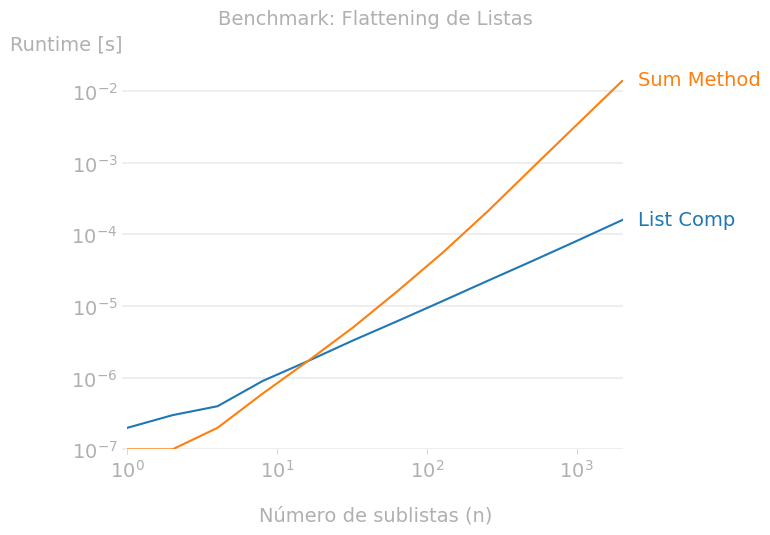

In [27]:
import perfplot
import numpy as np

perfplot.show(
    # Criamos uma lista de listas de forma segura (cada uma é um objeto único)
    setup=lambda n: [list(range(10)) for _ in range(n)],
    
    kernels=[
        lambda x: [item for sublist in x for item in sublist], # List Comprehension (Flatten)
        lambda x: sum(x, [])                                 # Sum method (Flatten)
    ],
    labels=["List Comp", "Sum Method"],
    n_range=[2**k for k in range(12)],
    xlabel="Número de sublistas (n)",
    title="Benchmark: Flattening de Listas"
)